### **Imports and other prerequisites**

In [ ]:
import json
import os
import warnings
warnings.filterwarnings('ignore')
import math
from math import erf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from nelson_siegel_svensson.calibrate import calibrate_nss_ols
from scipy.interpolate import Rbf
from BnS import BnS
from Heston import Heston

### **Initial configuration**

Linking data files and setting up some config parameters

In [2]:
CSV_PATH = "Data/gld_chain_wide_chain.csv"
META_JSON_PATH = "Data/gld_chain_wide_meta.json" 
OUTPUT_IV_PATH = "Data/gld_chain_with_iv_essential.csv"

DIVIDEND_YIELD = 0.0 # Assuming q=0 for GLD (Gold ETF)
MIN_PRICE = 1.0      # Remove options cheaper than 1$ to avoid bid/ask noise

# === FILTERS (MONEYNESS & TIME) ===

# === FILTERS (MONEYNESS & TIME) ===
MONEYNESS_WINDOW = 0.20 # Focus on +/- 20% around the Spot price
                        # Ignore deep Out/In The Money options to avoid IV spikes

T_MIN = 60.0 / 365.0 # Ignore options expiring in less than 60 days (avoid short-term noise)
MIN_POINTS_PER_EXPIRY = 5 # Minimum valid options required per expiration date

# Bisection parameters for Implied Volatility calculation
MIN_VOL = 1e-4
MAX_VOL = 5.0
VOL_TOL = 1e-8
MAX_ITERS = 200

### **Heston Model Calibration and Vega-Weighting**

In the calibration of the Heston model, adopting a cost function based on Vega-weighting is a crucial step. If one were to simply minimize the squared differences between theoretical and market prices, the optimization algorithm would be heavily biased towards deep In-The-Money (ITM) options, whose nominal premiums are orders of magnitude larger than those of Out-Of-The-Money (OTM) or At-The-Money (ATM) options.

Standard market practice involves minimizing the error directly on Implied Volatility in order to accurately reproduce the Volatility Smile across all strikes. However, numerically extracting the Implied Volatility for each option at every single iteration of the solver is computationally inefficient.

The solution consists of approximating the Implied Volatility error by leveraging a first-order Taylor series expansion. Since Vega ($\mathcal{V}$) represents the derivative of the option price with respect to volatility, the difference in volatility can be approximated by the ratio between the price difference and the Vega itself ($\Delta\sigma \approx \frac{\Delta P}{\mathcal{V}}$). Consequently, by weighting the price error with the inverse of the Black-Scholes Vega, we obtain an excellent and fast approximation of the volatility error. This approach ensures that all options, regardless of their moneyness and cost, contribute equitably and mathematically correctly to the fitting of the volatility surface.

### **Data recovery and validation**

Ensuring necessary variables and datasets are available in memory, loading them from disk if needed.

In [3]:
# --- SAFETY CHECK: Restore variables from disk if missing from memory ---
if 'DIVIDEND_YIELD' not in globals():
    DIVIDEND_YIELD = 0.0

if 'S0' not in globals():
    META_JSON_PATH = "Data/gld_chain_wide_meta.json"
    with open(META_JSON_PATH, "r", encoding="utf-8") as f:
        meta = json.load(f)
        for k in ["S0", "spot", "spot_price", "underlying_price", "underlying_last"]:
            if k in meta:
                S0 = float(meta[k])
                break
    print(f"[RECOVERY] Spot price (S0) restored from JSON: {S0:.2f}")

if 'dataset_chebyshev' not in globals():
    OUTPUT_CHEB_PATH = "Data/gld_iv_dataset_chebyshev.csv"
    if os.path.exists(OUTPUT_CHEB_PATH):
        dataset_chebyshev = pd.read_csv(OUTPUT_CHEB_PATH)
        print(f"[RECOVERY] 'dataset_chebyshev' loaded from disk: {len(dataset_chebyshev)} rows.")
    else:
        raise FileNotFoundError(f"Cannot find {OUTPUT_CHEB_PATH}. Please run the sampling cell first.")

[RECOVERY] Spot price (S0) restored from JSON: 437.82
[RECOVERY] 'dataset_chebyshev' loaded from disk: 64 rows.


### **Vega calculation**

Computing the Black-Scholes Vega for each option to use as weights in the calibration cost function.

In [4]:
print("[INFO] Calculating Black-Scholes Vega for the dataset...")

# Assuming S0 and DIVIDEND_YIELD are already defined in your notebook
q = DIVIDEND_YIELD if 'DIVIDEND_YIELD' in globals() else 0.0

dataset_chebyshev['vega'] = dataset_chebyshev.apply(
    lambda row: BnS.calculate_bs_vega(
        S=S0, 
        K=row['K'], 
        T=row['T'], 
        r=row['rate'], 
        q=q, 
        sigma=row['implied_vol'] # Use the IV you calculated earlier!
    ), 
    axis=1
)

print("[SUCCESS] 'vega' column added to dataset_chebyshev!")
display(dataset_chebyshev.head())

[INFO] Calculating Black-Scholes Vega for the dataset...
[SUCCESS] 'vega' column added to dataset_chebyshev!


,expiry,T,K,price,rate,implied_vol,vega
0,2026-06-30,0.242596,358.0,87.52,0.037163,0.371853,39.893144
1,2026-06-30,0.242596,375.0,72.74,0.037163,0.354184,50.784943
2,2026-06-30,0.242596,395.0,56.57,0.037163,0.336587,64.543165
3,2026-06-30,0.242596,425.0,35.85,0.037163,0.316880,81.571765
4,2026-06-30,0.242596,455.0,20.77,0.037163,0.307369,85.422635


### **Model calibration execution**

Running the optimization algorithms to find the best-fitting Heston parameters.

In [5]:
# Run the stable calibration on the Chebyshev dataset
optimal_params = Heston.calibrate_heston(dataset_chebyshev, S0)

[INFO] Starting Global Calibration (Differential Evolution)...
differential_evolution step 1: f(x)= 0.001097188605588243
differential_evolution step 2: f(x)= 0.001097188605588243
differential_evolution step 3: f(x)= 0.00025706794215601405
differential_evolution step 4: f(x)= 0.00025706794215601405
differential_evolution step 5: f(x)= 0.00011929238339096448
differential_evolution step 6: f(x)= 0.00011929238339096448
differential_evolution step 7: f(x)= 6.105924648080456e-05
differential_evolution step 8: f(x)= 6.105924648080456e-05
differential_evolution step 9: f(x)= 6.105924648080456e-05
differential_evolution step 10: f(x)= 5.6337134376267586e-05
differential_evolution step 11: f(x)= 5.6337134376267586e-05
differential_evolution step 12: f(x)= 5.6337134376267586e-05
differential_evolution step 13: f(x)= 4.472116643403598e-05
differential_evolution step 14: f(x)= 4.472116643403598e-05
differential_evolution step 15: f(x)= 4.472116643403598e-05
differential_evolution step 16: f(x)= 3.0

### **Visualizations**

Generating Volatility Smile grids to compare Market IV against the theoretical Heston Model IV across different maturities.

[INFO] Generating Volatility Smile grid...


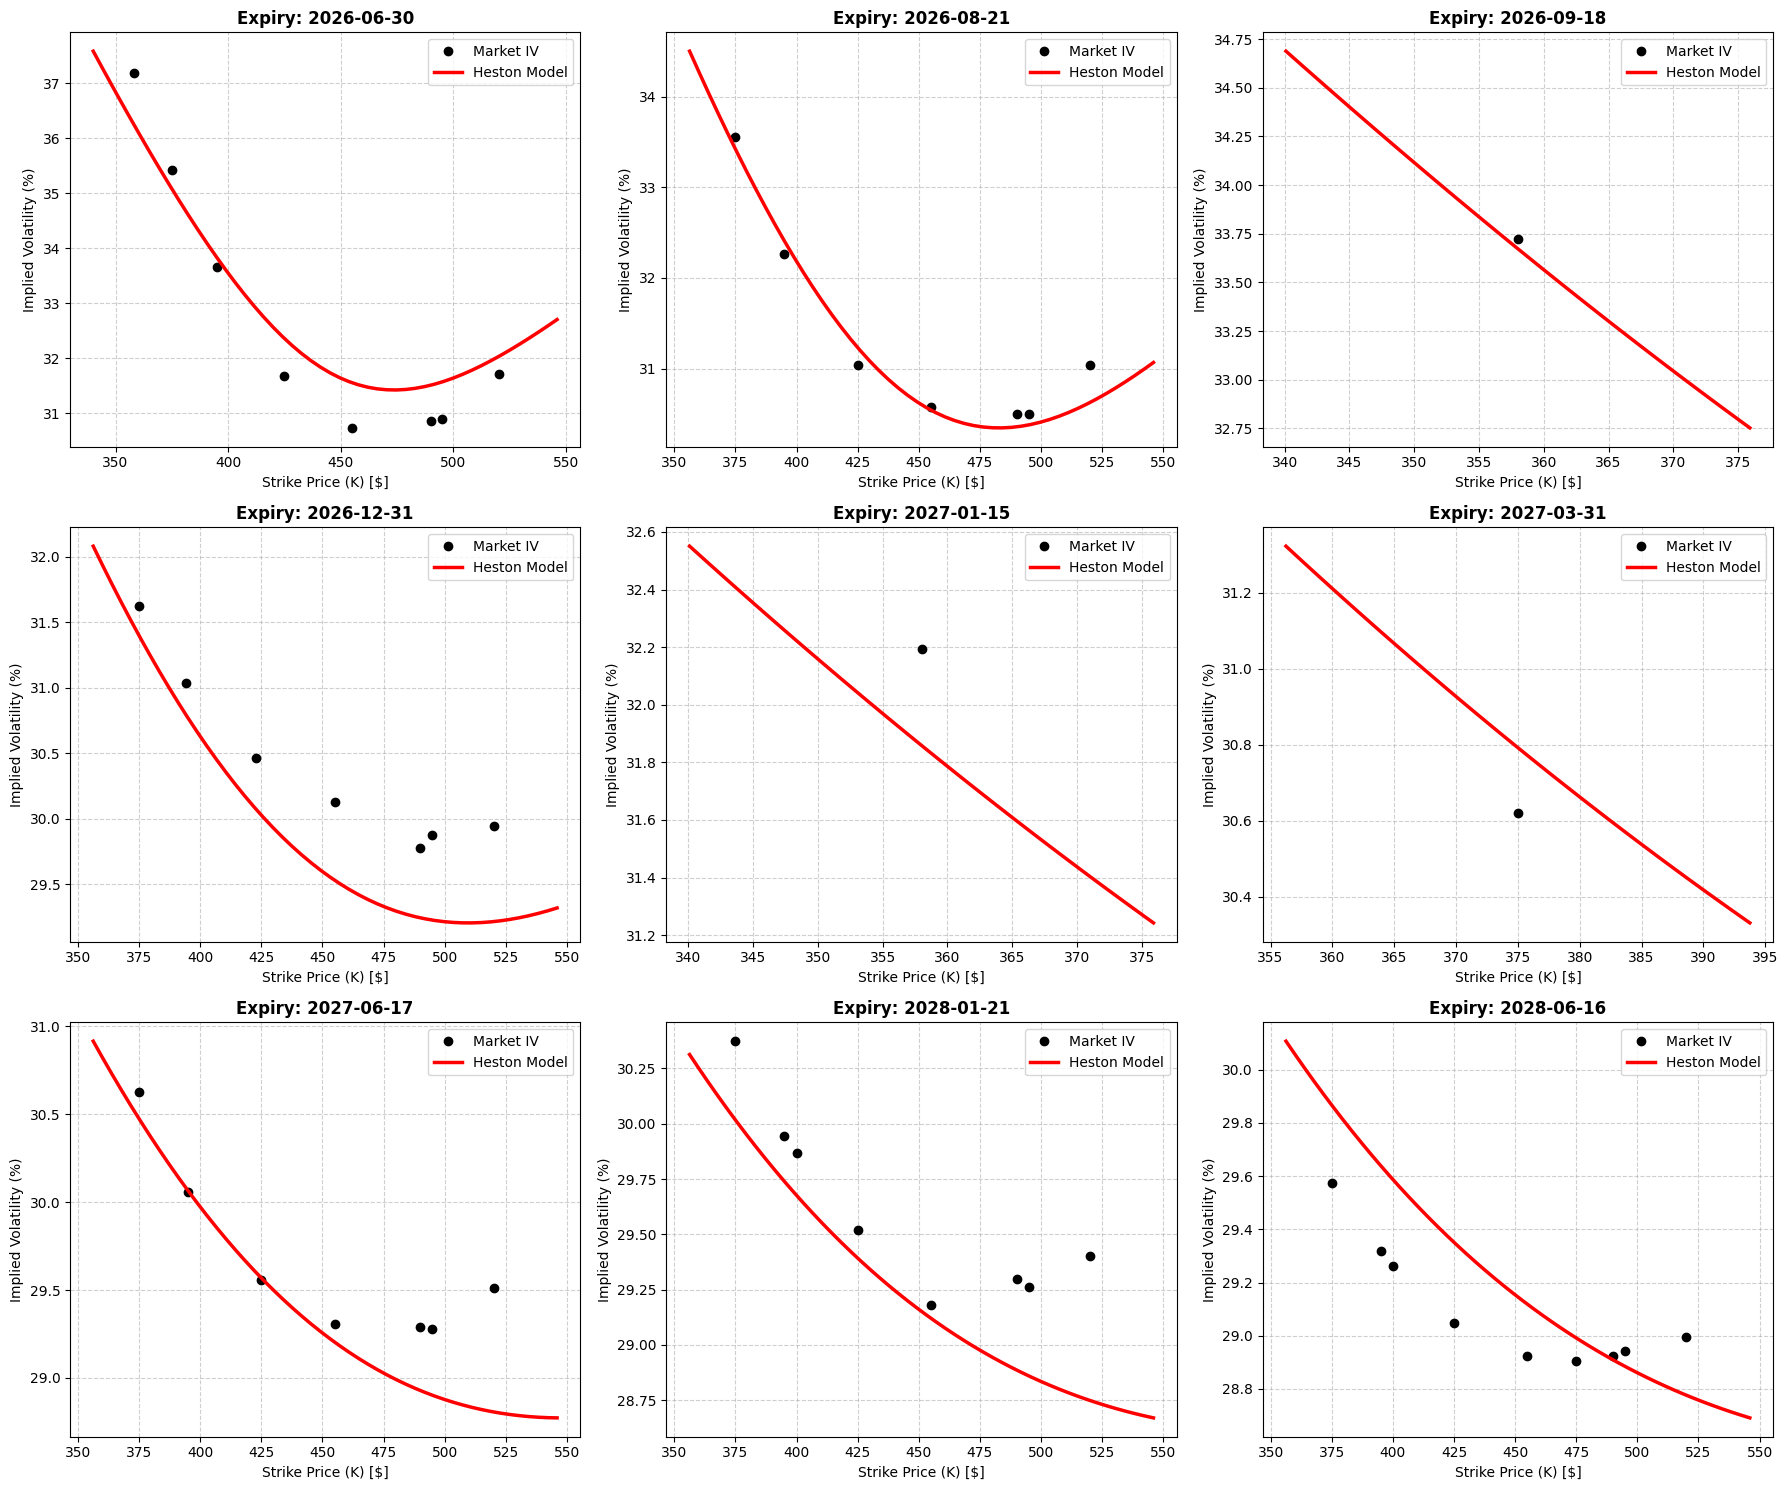

In [9]:
print("[INFO] Generating Volatility Smile grid...")

# Unpack your optimized parameters
v0, kappa, theta, sigma, rho = optimal_params

# Get the unique maturities (T) from your cleaned dataset
maturities = sorted(dataset_chebyshev['T'].unique())

# --- OPTIONAL: EXCLUDE MATURITIES ---
# If some maturities don't look good graphically, you can exclude them here.
# Example: exclude_maturities = [0.03835616, 0.5]
exclude_maturities = [2.7057239477318937]
maturities = [m for m in maturities if m not in exclude_maturities]
num_maturities = len(maturities)

# --- GRID CALCULATION ---
# Set maximum number of columns per row (3 looks great on most screens)
cols = min(3, num_maturities)
# Calculate how many rows we need to fit all maturities
rows = math.ceil(num_maturities / cols)

# Set up the figure with the new grid dimensions
fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))

# Flatten the axes array so we can easily loop through it, whether it's 1D or 2D
if num_maturities == 1:
    axes = np.array([axes])
else:
    axes = axes.flatten()

for i, T in enumerate(maturities):
    ax = axes[i]
    
    # 1. Filter the market data for this specific maturity
    df_T = dataset_chebyshev[dataset_chebyshev['T'] == T]
    
    # Plot the Market IV as black dots
    ax.plot(df_T['K'], df_T['implied_vol'] * 100, 'ko', markersize=6, label='Market IV')
    
    # 2. Generate a smooth theoretical Heston Curve
    K_min, K_max = df_T['K'].min(), df_T['K'].max()
    K_grid = np.linspace(K_min * 0.95, K_max * 1.05, 50)
    
    r = df_T['rate'].iloc[0] 
    q = 0.0 # Dividend yield for GLD
    
    heston_iv_curve = []
    
    for K in K_grid:
        # Calculate Theoretical Heston Price 
        h_price = Heston.heston_price_fast(S0, K, T, v0, kappa, theta, sigma, rho, r, q)
        
        # Convert Heston Price back to Implied Volatility
        h_iv = BnS.implied_vol_call(price=h_price, S=S0, K=K, T=T, r=r, q=q)
        
        # Protect against root-finder failures on extreme wings
        if np.isnan(h_iv) or h_iv <= 0:
            heston_iv_curve.append(np.nan)
        else:
            heston_iv_curve.append(h_iv * 100)
            
    # Plot the Heston Model IV as a smooth red line
    ax.plot(K_grid, heston_iv_curve, 'r-', linewidth=2.5, label='Heston Model')
    
    # 3. Chart Formatting
    expiry_date = df_T['expiry'].iloc[0] if 'expiry' in df_T.columns else f"T={T:.2f}"
    
    ax.set_title(f'Expiry: {expiry_date}', fontweight='bold')
    ax.set_xlabel('Strike Price (K) [$]')
    ax.set_ylabel('Implied Volatility (%)')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend()

# --- CLEANUP ---
# If we have a 3x3 grid (9 slots) but only 8 maturities, hide the last empty slot
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Residual Heatmap (Market vs. Heston)**

In this section, we graphically analyze the structural limitations of the Heston Model.
We calculate the difference between the real Implied Volatility (Market) and the one priced by our calibrated model. The result is projected onto a *Scatter-Heatmap* based on Time to Maturity (X-axis) and Moneyness (Y-axis).

Intensely colored zones (usually short-maturity and *Out-Of-The-Money*) highlight the areas where pure continuous diffusion dynamics are insufficient to price the risk premiums demanded by traders. This empirical evidence justifies the introduction of Jump-Diffusion processes.

[INFO] Calculating Heston theoretical Implied Volatilities for residuals...
[INFO] Heatmap generation completed on 64 valid points...


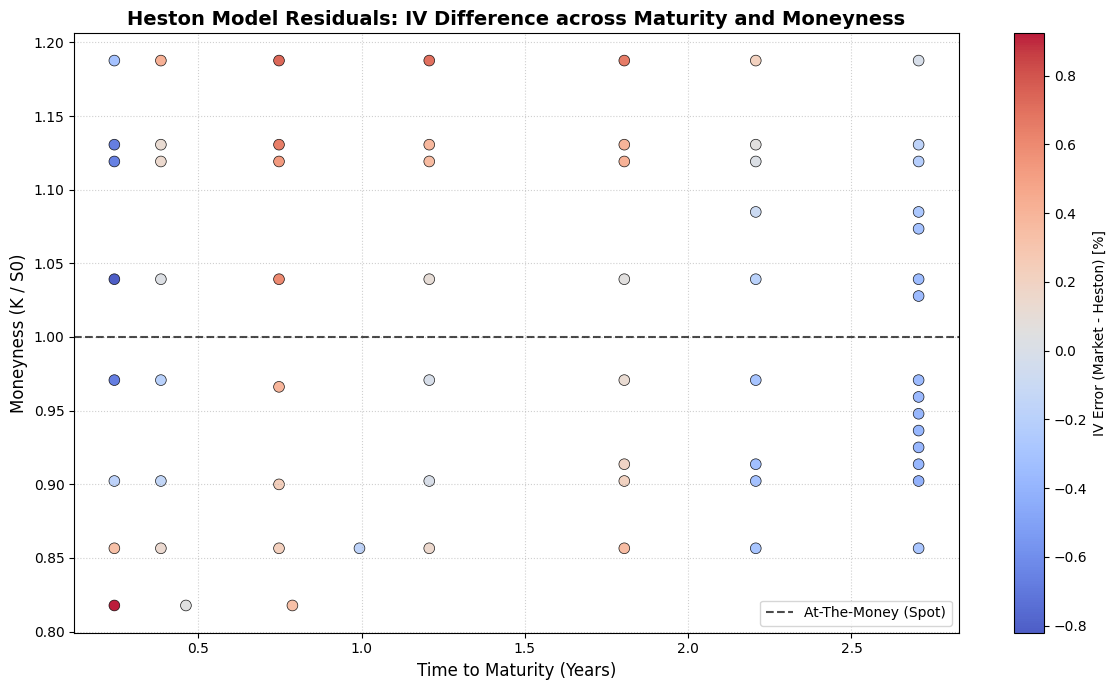

In [13]:
print("[INFO] Calculating Heston theoretical Implied Volatilities for residuals...")

# Ensure we use the optimized parameters and global variables already in memory
v0, kappa, theta, sigma, rho = optimal_params
q = DIVIDEND_YIELD if 'DIVIDEND_YIELD' in globals() else 0.0

residuals_list = []

# Iterate over the previously generated dataset_chebyshev
for _, row in dataset_chebyshev.iterrows():
    K = row['K']
    T = row['T']
    r = row['rate']
    market_iv = row['implied_vol']
    
    # 1. Calculate theoretical Heston price
    h_price = Heston.heston_price_fast(S0, K, T, v0, kappa, theta, sigma, rho, r, q)
    
    # 2. Convert it back to Implied Volatility via bisection
    h_iv = BnS.implied_vol_call(price=h_price, S=S0, K=K, T=T, r=r, q=q)
    
    # 3. Save results, discarding any numerical errors (NaNs)
    if not np.isnan(h_iv) and h_iv > 0:
        moneyness = K / S0
        iv_residual = (market_iv - h_iv) * 100  # Error in percentage points
        residuals_list.append({
            'T': T, 
            'moneyness': moneyness, 
            'iv_residual': iv_residual
        })

df_residuals = pd.DataFrame(residuals_list)
print(f"[INFO] Heatmap generation completed on {len(df_residuals)} valid points...")

# --- CHART CREATION ---
plt.figure(figsize=(12, 7))

# Scatter plot with a divergent colormap (coolwarm)
# Red = Heston underestimates market volatility
# Blue = Heston overestimates market volatility
scatter = plt.scatter(
    df_residuals['T'], 
    df_residuals['moneyness'], 
    c=df_residuals['iv_residual'], 
    cmap='coolwarm', 
    s=60, 
    edgecolors='k', 
    linewidth=0.5,
    alpha=0.9
)

plt.colorbar(scatter, label='IV Error (Market - Heston) [%]')
plt.axhline(1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.7, label='At-The-Money (Spot)')

plt.title('Heston Model Residuals: IV Difference across Maturity and Moneyness', fontsize=14, fontweight='bold')
plt.xlabel('Time to Maturity (Years)', fontsize=12)
plt.ylabel('Moneyness (K / S0)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig("Data/heston_residual_heatmap.png", dpi=300)
plt.show()